In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import csv
import os
from scipy.stats import kendalltau
from scipy import stats
import numpy as np
import cartopy.crs as ccrs
import cartopy
import xarray as xr
import rioxarray
import geopandas as gpd

In [80]:
tp_ds = monthly_misc.tp
t2m = monthly_temp.t2m

In [27]:
# Store site metadata (site number, site name, catchment number, NZTME, NZTMN)

metadata_df = pd.read_csv('/nesi/project/niwa00015/queenle/data/metadata/40_50yr_sites.csv')
metadata_df.set_index('Number',inplace=True)

seasonal_flow_df = pd.read_csv('/nesi/project/niwa00015/queenle/data/flows/seasonal/50yrs/new_full_records.csv')
seasonal_flow_df.date = pd.to_datetime(seasonal_flow_df.date)
seasonal_flow_df.set_index('date', inplace=True)

daily_flow_df = pd.read_csv('/nesi/project/niwa00015/queenle/data/flows/daily/50yrs/full_records.csv')
daily_flow_df.Date = pd.to_datetime(daily_flow_df.Date)
daily_flow_df.set_index('Date', inplace=True)
mean_flow_df = daily_flow_df.resample('A').mean().mean()

# load catchment shape data
fp = '/nesi/project/niwa00015/queenle/data/arcgis/'
file = 'NESTCAT_v2_NZTM.shp'
catchment_data = gpd.read_file(fp+file)
catchment_data = catchment_data.to_crs("EPSG:4326")
catchment_data = catchment_data.loc[catchment_data['SITE'].isin(seasonal_flow_df.columns)]
catchment_data.index = catchment_data['SITE']


# define alpha and numeric season order
seasons_a = ['Winter','Spring','Summer','Autumn']
seasons_n = [6,9,12,3]

71132       83242.748476
46618        9369.181255
64602       96653.215856
71135        8244.025500
77505       18139.378763
16501       88964.692382
1043427     11320.342071
71120       80262.984836
71129        3183.067415
62103       22491.637580
1316         6013.020688
46651        8069.286775
33316       34743.303850
9205        37353.983328
68001        3182.285586
32503       14782.267133
78625        1977.214633
60104         645.567651
75292      197279.604612
3506          440.079878
43472        3647.998521
1043428      4596.419748
4901          398.831299
73501         684.351242
60114       26860.536803
15408       21341.021983
62105       14385.043420
79713       12930.217373
29808        7689.922365
21412       17530.392141
1043466      6303.872895
75288       64362.315577
69621         321.655940
52916        3681.871216
23104       17118.623431
33347        1402.847078
21801       77808.405114
68806       10666.800690
15410       14984.570163
71116       23240.749727


In [32]:
monthly_misc = xr.open_dataset('/nesi/project/niwa00015/queenle/data/ERA5/monthly/1969_2019_all.nc').resample(time='A').sum().mean('time')
monthly_temp = xr.open_dataset('/nesi/project/niwa00015/queenle/data/ERA5/monthly/temp/1959_2019.nc').sel(time=slice('1969', '2019')).resample(time='A').mean().mean('time')

new_lon = np.linspace(monthly_misc.longitude[0], monthly_misc.longitude[-1], len(monthly_misc.longitude.values) * 10)
new_lat = np.linspace(monthly_misc.latitude[0], monthly_misc.latitude[-1], len(monthly_misc.latitude.values) * 10)

monthly_misc = monthly_misc.interp(latitude=new_lat, longitude=new_lon,method='linear')
monthly_temp = monthly_temp.interp(latitude=new_lat, longitude=new_lon,method='linear')

tp_ds = monthly_misc.tp
tp_ds = tp_ds.rio.write_crs("EPSG:4326")
tp_ds.rio.set_spatial_dims('longitude', 'latitude', inplace=True)

t2m_ds = monthly_temp.t2m
t2m_ds = t2m_ds.rio.write_crs("EPSG:4326")
t2m_ds.rio.set_spatial_dims('longitude', 'latitude', inplace=True)


<xarray.DataArray 't2m' (latitude: 610, longitude: 610)>
array([[291.06729126, 291.0646003 , 291.06190934, ..., 290.58816243,
        290.58827067, 290.58837891],
       [291.05310585, 291.05045932, 291.0478128 , ..., 290.57347701,
        290.57357517, 290.57367334],
       [291.03892044, 291.03631834, 291.03371625, ..., 290.55879159,
        290.55887968, 290.55896778],
       ...,
       [282.51733714, 282.52059242, 282.5238477 , ..., 281.49709406,
        281.49583112, 281.49456817],
       [282.50035253, 282.50363684, 282.50692115, ..., 281.48396985,
        281.48266188, 281.48135391],
       [282.48336792, 282.48668126, 282.48999459, ..., 281.47084564,
        281.46949264, 281.46813965]])
Coordinates:
  * latitude     (latitude) float64 -33.0 -33.02 -33.05 ... -47.95 -47.98 -48.0
  * longitude    (longitude) float64 165.0 165.0 165.0 ... 180.0 180.0 180.0
    spatial_ref  int64 0
Attributes:
    grid_mapping:  spatial_ref

In [28]:
monthly_misc = xr.open_dataset('/nesi/project/niwa00015/queenle/data/ERA5/monthly/1969_2019_all.nc').resample(time='A').sum()


In [40]:
tp_ds.rio.clip(catchment_geo.geometry,catchment_geo.crs).mean(['latitude','longitude']).values.tolist()

0.07984701387335444

In [4]:
elev_ds = xr.open_dataset('/home/stoneda/data/obs/NOAA-NCEI/ETOPO1/1x1minute/fx/atmos/orog/ETOPO1-Ice-Surface/ETOPO1_Ice_g_gmt4.grd.nc')
nz_elev_ds = elev_ds.sel(lat=slice(-48,-33),lon=slice(163,200)).orog
nz_elev_ds = nz_elev_ds.rio.write_crs("EPSG:4326")
nz_elev_ds.rio.set_spatial_dims('lon', 'lat', inplace=True)

crs = ccrs.Mercator()

def calc_elevation_range(catchment_data):
    
    clipped = nz_elev_ds.rio.clip(catchment_data.geometry,catchment_data.crs)
    
    mn = min(val for val in clipped.values.flatten() if not np.isnan(val))
    mx = max(val for val in clipped.values.flatten() if not np.isnan(val))
    
    return "(" + str(mn) + ", " + str(mx) + ")"

In [19]:
table1 = metadata_df.loc[[int(s) for s in seasonal_flow_df.columns]][['Name','gauge_lat','gauge_lon','area_km2']]

site = table1.index[3]

print(site)

catchment_geo = catchment_data.loc[[float(site)]]
    
tp_ds.rio.clip(catchment_geo.geometry,catchment_geo.crs).mean(['latitude','longitude'])

71135


<xarray.DataArray 'tp' ()>
array(0.00748942)
Coordinates:
    spatial_ref  int64 0

In [47]:
# METADATA TABLE

table1 = metadata_df.loc[[int(s) for s in seasonal_flow_df.columns]][['Name','gauge_lat','gauge_lon','area_km2']]

start_dates = []
end_dates = []
elev_ranges = []
mean_flows = []
temps = []
precips = []
for site in table1.index:
    full_record = daily_flow_df[str(site)]
    date_list = full_record.index.tolist()
    
    
    # find start and end dates of active record
    for time in date_list:
        if not np.isnan(full_record.loc[time]):
            start_dates.append(time.strftime('%m-%Y'))
            break
            
    date_list.reverse()
    for time in date_list:
        if not np.isnan(full_record.loc[time]):
            end_dates.append(time.strftime('%m-%Y'))
            break

    # add mean flow of record
    mean_flows.append(mean_flow_df[str(site)])
    
    if site == 4901.0:
        precips.append("")
        temps.append("")
        elev_ranges.append("")
        continue
        
    catchment_geo = catchment_data.loc[[float(site)]] if site != 4901.0 else None
    
    # find elevation range of catchment
    elev_ranges.append(calc_elevation_range(catchment_geo))
    
    # add ERA5 tp and t2m
    precips.append(tp_ds.rio.clip(catchment_geo.geometry,catchment_geo.crs).mean(['latitude','longitude']).values.tolist())
    temps.append(t2m_ds.rio.clip(catchment_geo.geometry,catchment_geo.crs).mean(['latitude','longitude']).values.tolist() - 273.15)
    
table1['Start Date'] = start_dates
table1['End Date'] = end_dates   
table1['Elevation Range (m)'] = elev_ranges
table1['Mean Annual Flow (L/s)'] = mean_flows
table1['Mean Annual Precipitation (m)'] = precips
table1['Mean Annual Temperature (K)'] = temps

table1.columns = ['Name','Gauge Latitude','Gauge Longitude','Area (km^2)','Start Date','End Date','Elevation Range (m)', 'Mean Flow (L/s)','Mean Annual Precipitation (m)','Mean Annual Temperature (K)']


table1.to_csv('streamflow_network_metadata.csv')

In [45]:
table1

,Name,Gauge Latitude,Gauge Longitude,Area (km^2),Start Date,End Date,Elevation Range (m),Mean Flow (L/s),Mean Annual Precipitation (m),Mean Annual Temperature (K)
Number,,,,,,,,,,
71132,Lake Tekapo at Power Station Intake,-44.00,170.47,1420.000000,12-1931,12-2017,"(710.0, 2376.0)",83242.748476,21.5218,3.2296
46618,Mangakahia at Gorge,-35.63,173.85,246.000000,12-1960,01-2020,"(91.0, 649.0)",9369.181255,1.89676,14.0112
64602,Waiau at Marble Point,-42.65,172.77,1980.000000,10-1967,12-2019,"(298.0, 1828.0)",96653.215856,20.9652,5.87004
71135,Jollie at Mt Cook Stn,-43.86,170.18,139.000000,12-1964,01-2020,"(701.0, 2195.0)",8244.025500,2.51645,2.45473
77505,Mataura at Parawa,-45.56,168.56,766.000000,12-1955,01-2020,"(274.0, 1654.0)",18139.378763,8.59305,4.79248
16501,Motu at Houpoto,-37.86,177.63,1393.000000,04-1957,01-2020,"(114.0, 1317.0)",88964.692382,14.1106,11.0219
1043427,Mangakino at Dillon Rd,-38.41,175.73,337.000000,04-1964,01-2020,"(239.0, 1027.0)",11320.342071,3.3494,11.1176
71120,Lake Ohau at Lake Middleton,-44.28,169.85,1190.000000,12-1931,12-2017,"(519.0, 2147.0)",80262.984836,17.5446,3.94039
71129,Forks at Balmoral,-43.98,170.40,98.000000,07-1962,01-2020,"(822.0, 2078.0)",3183.067415,1.46746,3.58452


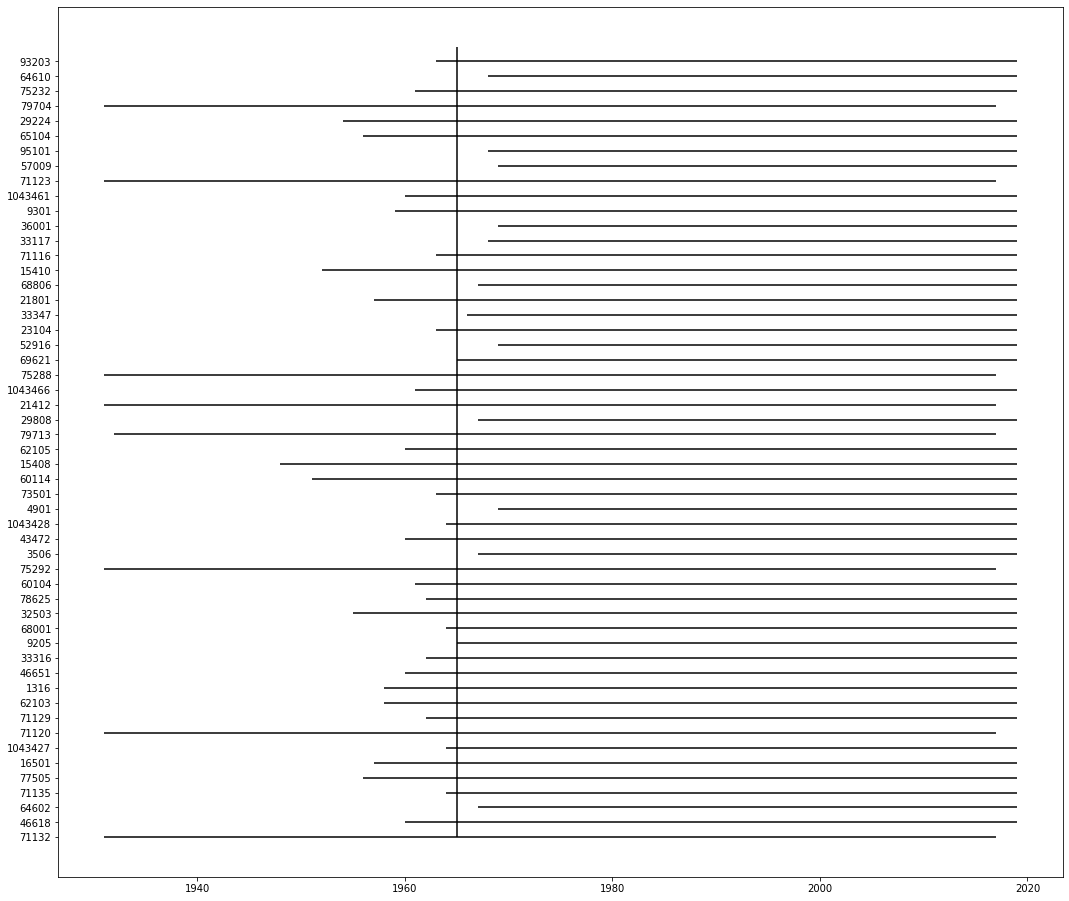

In [5]:
fig,ax = plt.subplots(figsize=(18,16))

ticks = []
labels = []
for i,site in enumerate(table1.index):
    start = int(table1.loc[site]['Start Date'][-4:])
    end = int(table1.loc[site]['End Date'][-4:])

    plt.hlines(i,start,end)
    labels.append(site)
    ticks.append(i)

plt.yticks(ticks,labels)

plt.vlines(1965,0,53)

In [3]:
# LOCAL RESULTS

for s,season in enumerate(seasons_n):
    
    season_table2 = metadata_df.loc[[int(s) for s in flow_df.columns]][['Name']]
        
    shared_season = flow_df[flow_df.index.month.isin([season])]['1969':'2019']
    full_season = flow_df[flow_df.index.month.isin([season])]
    
    shared_tau = []
    shared_p = []
    full_tau = []
    full_p = []
    for site in season_table2.index:

        years = shared_season[str(site)].index.year.values
        time_series = shared_season[str(site)].values
        
        coef, p = kendalltau(years, time_series, nan_policy='omit')
        
        shared_tau.append(coef)
        shared_p.append(p)
                
        years = full_season[str(site)].index.year.values
        time_series = full_season[str(site)].values

        coef, p = kendalltau(years, time_series, nan_policy='omit')
        
        full_tau.append(coef)
        full_p.append(p)
        
    season_table2['50-year Tau'] = shared_tau
    season_table2['50-year P'] = shared_p
    season_table2['Full Record Tau'] = full_tau
    season_table2['Full Record P'] = full_p
    
    season_table2.to_csv(seasons_a[s] + '_trends.csv')
    
    
    

    

In [4]:
winter = {1: [1316, 3506, 46618, 46651, 4901, 9301],
          2: [1043427, 1043428, 1043461, 1043466, 15408, 15410, 16501, 32503, 9205,
                       21412, 21801, 23104, 29224, 29808, 33117, 33316, 33347, 36001, 43472],
          3: [52916, 57009, 60114, 64602, 65104, 71116, 71120, 71123, 71129, 
              71132, 71135, 75232, 75288, 75292, 77505, 78625, 79704, 79713, 93203, 95101],
          4: [60104, 62105, 64610, 68001, 68806, 69621, 73501, 62103], 
         }

winter_names = {1: 'Northland',2: 'Central North Island',3:'West South Island',4:'East South Island'}
                   
summer = {1: [1043427, 1043428, 1043461, 1316, 15410, 16501, 21412, 21801, 23104, 32503, 
              33316, 3506, 43472, 46618, 46651, 4901, 9205, 9301, 15408],
          2: [1043466, 29224, 29808, 33117, 33347, 36001],
          3: [60114, 64602, 65104, 71116, 71120, 71123, 71129, 71132, 71135, 75232, 
              75288, 75292, 77505, 78625, 79704, 79713, 93203, 95101,52916],
          4: [57009, 60104, 62103, 62105, 64610, 68001, 68806, 69621,73501]
          }

summer_names = {1:'Northland', 2:'South North Island', 3:'West South Island', 4:'East South Island'}

autumn = {1: [1043427, 1043428, 1043461, 1043466, 1316, 15408, 15410, 16501, 21412, 21801, 
              23104, 32503, 33316, 33347, 3506, 43472, 46618, 46651, 4901, 9205, 9301],
          2: [29224, 29808, 33117, 36001, 52916, 57009, 60104, 60114, 62103, 62105, 64602, 
              64610, 65104, 68001, 68806, 69621, 71116, 71120, 71123, 71129, 71132, 71135, 
              73501, 75232, 75288, 75292, 77505, 78625, 79704, 79713, 93203, 95101]
         }

autumn_names = {1:'North', 2:'South'}

spring = {1: [1043427, 1043428, 1316, 15408, 15410, 16501, 21412, 21801, 23104, 32503, 
              3506, 43472, 46618, 46651, 4901, 60104, 64610, 68001, 69621, 73501, 9205, 9301],
          2: [1043461, 1043466, 29224, 29808, 33117, 33316, 33347, 36001, 52916, 57009, 
              60114, 62103, 62105, 64602, 65104, 68806, 71116, 71120, 71123, 71129, 71132, 
              71135, 75232, 75288, 75292, 77505, 78625, 79704, 79713, 93203, 95101]
          }
spring_names = {1: 'East', 2: 'West'}

cluster_lists = {6:winter,9:spring,12:summer,3:autumn}
names_list = {6:winter_names,9:spring_names,12:summer_names,3:autumn_names}

In [5]:
# REGIONAL RESULTS

#season // region // start_date // tau // p

seasons = []
regions = []
start_years = []
taus = []
ps = []

for i in range(4):
    
    s = seasons_n[i]
    
    cluster_dict = cluster_lists[s]
    cluster_names = names_list[s]

    df = flow_df[flow_df.index.month.isin([s])]

    for c in cluster_dict:

        cluster_df = df[[str(num) for num in cluster_dict[c]]]

        multiple_records_year = 0
        for j in range(len(cluster_df.index)):
            if np.count_nonzero(~np.isnan(cluster_df.iloc[j]))>1:
                multiple_records_year = str(cluster_df.index[j].year)
                break

        cluster_df = cluster_df[multiple_records_year:]
        cluster_df = (cluster_df - cluster_df.mean())/cluster_df.std()
        
        averaged_cluster = cluster_df.mean(axis=1,skipna=True)

        vals = averaged_cluster.values
        years = averaged_cluster.index.year.values

        coef, p = kendalltau(years,vals,nan_policy='omit')
        
        seasons.append(seasons_a[i])
        regions.append(cluster_names[c])
        start_years.append(multiple_records_year)
        taus.append(coef)
        ps.append(p)
        
df = pd.DataFrame.from_dict({'Season':seasons,'Region':regions,'Start Year':start_years,'Tau':taus,'P-value':ps})
df = df.set_index('Season')
df.to_csv('regional_trends.csv')